# Stage 1: The Gatekeeper

In [7]:
%pip install fastapi uvicorn streamlit requests pandas numpy scikit-learn imbalanced-learn pydantic python-multipart pypdf llama-cpp-python


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [8]:
# Load the final verified corpus (first 2000 rows)
import pandas as pd

# Read only the first 4000 rows
corpus = pd.read_csv('final_corpus_verified - Sheet1.csv', nrows=4000)
corpus.head()

,Requirement Text,Class,Sub-Type,Ambiguity
0,The app shall run on a smart phone with Androi...,NFR,Maintainability,Non-Ambiguous
1,All layout shall be according to the TU/e corp...,NFR,Usability,Non-Ambiguous
2,The icons shall be according to the Android Ic...,NFR,Usability,Non-Ambiguous
3,The user interfaces shall be according to the ...,NFR,Usability,Non-Ambiguous
4,"The Twitter ""tweet"" interface shall be accordi...",NFR,Usability,Non-Ambiguous


/tmp/ipykernel_18018/4246084169.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=corpus, x='Class', ax=axes[0], palette='pastel', order=corpus['Class'].value_counts().index)
/tmp/ipykernel_18018/4246084169.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=corpus, x='Sub-Type', ax=axes[1], palette='pastel', order=corpus['Sub-Type'].value_counts().index)
/tmp/ipykernel_18018/4246084169.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=corpus, x='Ambiguity', ax=axes[2], palette='pastel', order=corpus['Ambiguity'].

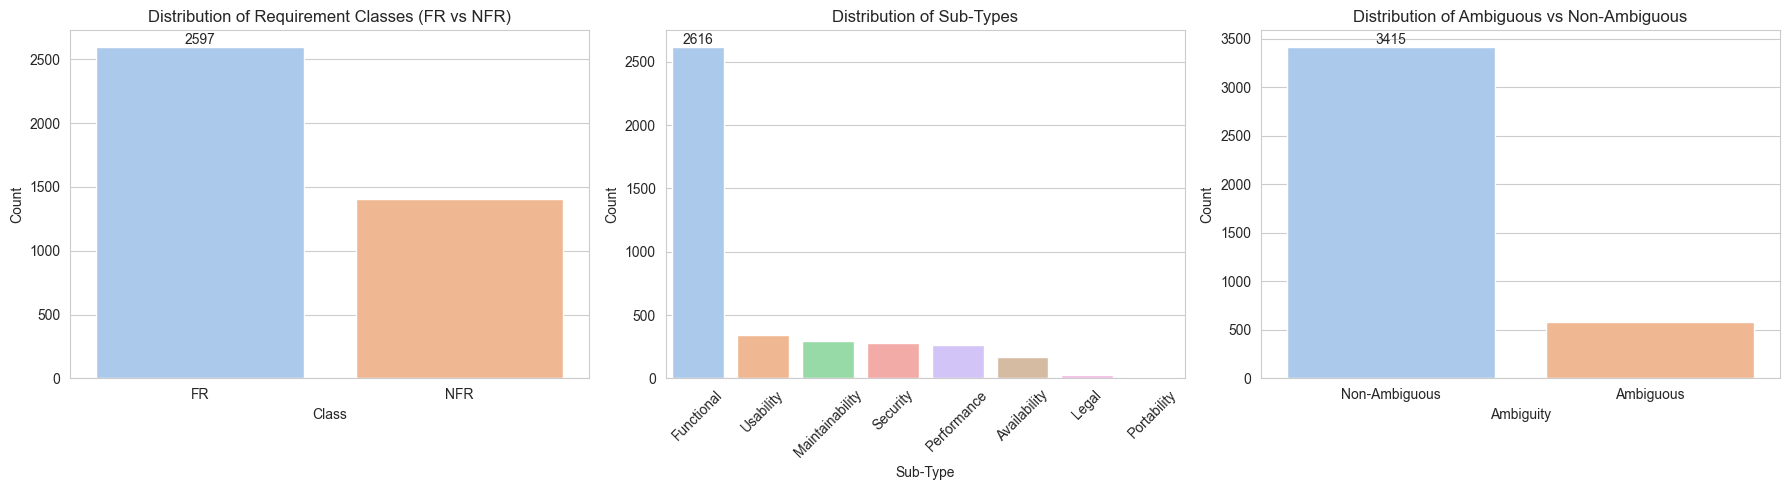

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_style('whitegrid')

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Chart: Distribution of FR vs NFR
sns.countplot(data=corpus, x='Class', ax=axes[0], palette='pastel', order=corpus['Class'].value_counts().index)
axes[0].set_title('Distribution of Requirement Classes (FR vs NFR)')
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0])

# 2. Chart: Distribution of Sub-Types
sns.countplot(data=corpus, x='Sub-Type', ax=axes[1], palette='pastel', order=corpus['Sub-Type'].value_counts().index)
axes[1].set_title('Distribution of Sub-Types')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45) # Rotate x labels for better readability
axes[1].bar_label(axes[1].containers[0])

# 3. Chart: Distribution of Ambiguity
sns.countplot(data=corpus, x='Ambiguity', ax=axes[2], palette='pastel', order=corpus['Ambiguity'].value_counts().index)
axes[2].set_title('Distribution of Ambiguous vs Non-Ambiguous')
axes[2].set_ylabel('Count')
axes[2].bar_label(axes[2].containers[0])

plt.tight_layout()
plt.show()

In [10]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample
import pandas as pd

# Download required NLTK data (safe to call multiple times)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()
# We combine standard english stopwords with domain-specific boilerplate words
# IMPROVEMENT: Added 'app', 'data', and 'network' to prevent shortcut learning
stop_words = set(stopwords.words('english'))
domain_stopwords = {'shall', 'must', 'system', 'application', 'ensure', 'provide', 'able', 'user', 'users', 'app', 'data', 'network'}
all_stopwords = stop_words.union(domain_stopwords)

# --- 1. Regex Cleaning, Lowercasing, and Length Threshold ---

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    
    # Strip numerical bullet points at start (e.g., "1. ", "1.1.", "2)")
    text = re.sub(r'^\s*(?:\d+[\.\)]\s*)+', '', text)
    
    # Tokenize numbers (replace digits/decimals with the explicit 'numtoken' keyword)
    # This prevents the SVM from overfitting to specific requirement targets (like "99", "12")
    text = re.sub(r'\b\d+(?:\.\d+)?\b', 'numtoken', text)
    
    # Remove non-alphanumeric punctuation
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # NLP processing: Tokenize by spacing, remove stopwords, and lemmatize
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in all_stopwords]
    
    return " ".join(cleaned_words)

corpus['cleaned_text'] = corpus['Requirement Text'].apply(clean_text)

# Drop any row containing fewer than 3 words (Threshold lowered from 5 to 3 since stopwords are stripped)
corpus = corpus[corpus['cleaned_text'].apply(lambda x: len(x.split()) >= 3)]

# --- 2. Label Harmonization & Deduplication ---

# Binary Mapping: FR -> 0, NFR -> 1
corpus['label'] = corpus['Class'].apply(lambda x: 0 if str(x).strip().upper() == 'FR' else 1)

# Aggressive Deduplication: Drop all rows with identical cleaned text
corpus = corpus.drop_duplicates(subset=['cleaned_text'])

print(f"Dataset size after cleaning and deduplication: {len(corpus)}")

# --- 3. Balancing the Dataset (Before Splitting) ---

# Class Balancing: downsample the majority class based on the lowest label count
class_counts = corpus['label'].value_counts()
print(f"\nClass counts before balancing:\n{class_counts}")

minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
minority_count = class_counts.min()

corpus_majority = corpus[corpus['label'] == majority_class]
corpus_minority = corpus[corpus['label'] == minority_class]

corpus_majority_downsampled = resample(
    corpus_majority,
    replace=False,         # Sample without replacement
    n_samples=minority_count, # Match minority class count
    random_state=42
)

# Combine minority class with downsampled majority class
corpus_balanced = pd.concat([corpus_majority_downsampled, corpus_minority])
# Shuffle appropriately
corpus_balanced = corpus_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nClass counts after balancing:\n{corpus_balanced['label'].value_counts()}")

# --- 4. Splitting and Vectorization ---

X_balanced = corpus_balanced['cleaned_text']
y_balanced = corpus_balanced['label']

# 80/20 train-test split (stratify is less crucial now since it's perfectly balanced, but good practice)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42
)

# TF-IDF Fitting (training on the 80% train section) using bigrams
# Added tf-idf tuning: min_df=3 strips very rare typo-words, max_df=0.85 removes extreme boilerplate words
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.85, min_df=3)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test) # merely transform 20% test data

print("\nTraining set shape:", X_train_vec.shape)
print("Test set shape:", X_test_vec.shape)

Dataset size after cleaning and deduplication: 3872

Class counts before balancing:
label
0    2518
1    1354
Name: count, dtype: int64

Class counts after balancing:
label
0    1354
1    1354
Name: count, dtype: int64

Training set shape: (2166, 1595)
Test set shape: (542, 1595)


SVM Classification Accuracy: 82.10%

Classification Report:
               precision    recall  f1-score   support

 FR (Class 0)       0.79      0.87      0.83       271
NFR (Class 1)       0.86      0.77      0.81       271

     accuracy                           0.82       542
    macro avg       0.82      0.82      0.82       542
 weighted avg       0.82      0.82      0.82       542



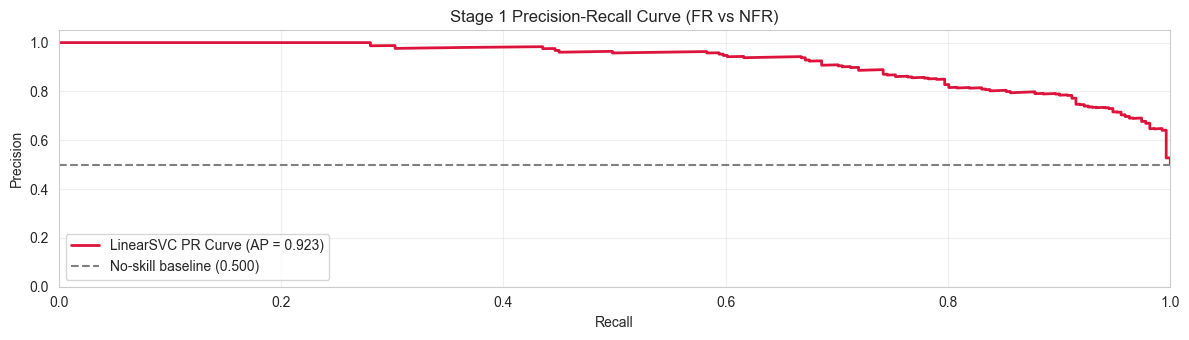

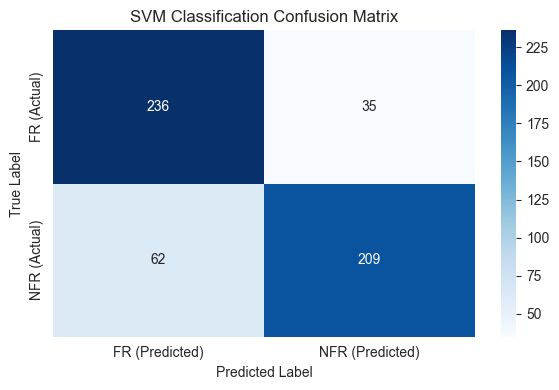

/tmp/ipykernel_18018/3687459125.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=abs(top_fr_coef), y=top_fr_words, palette="Greens_r")
/tmp/ipykernel_18018/3687459125.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_nfr_coef, y=top_nfr_words, palette="Reds_r")


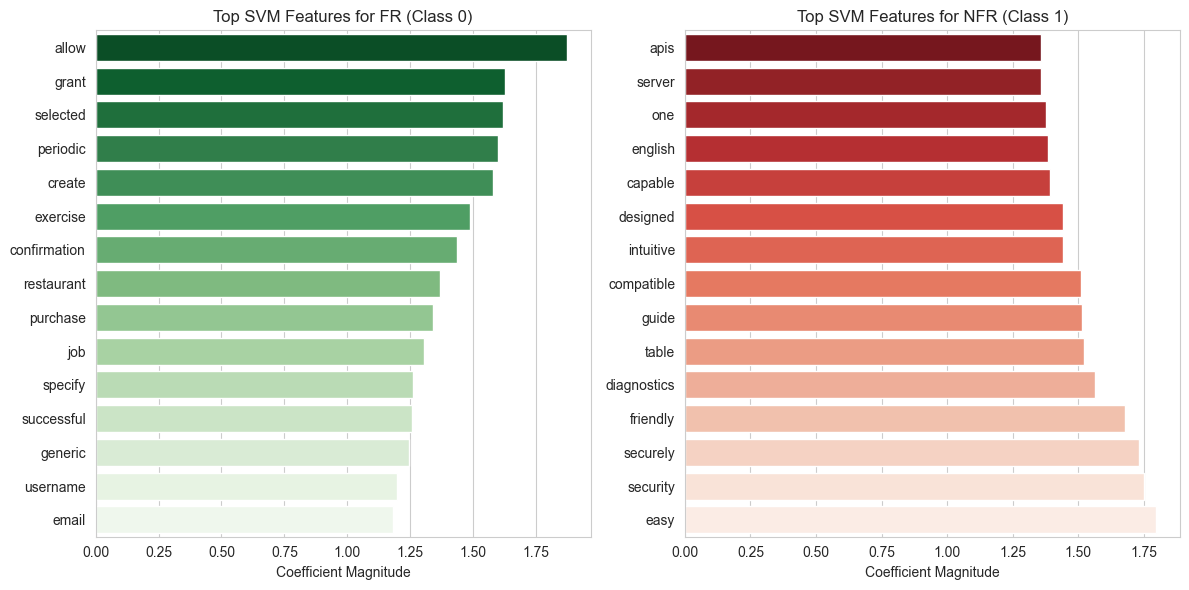

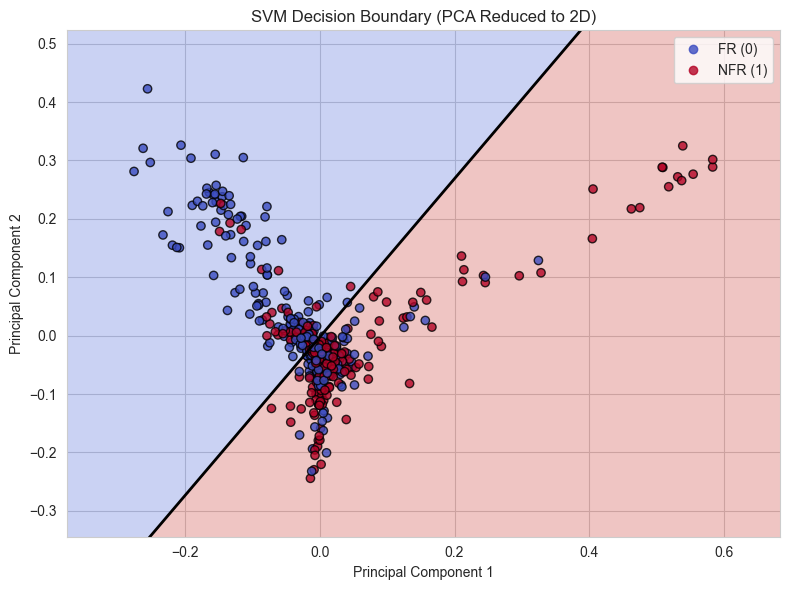

In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA

# --- 5. Train Support Vector Machine (SVM) ---

# Initialize the Linear SVM classifier 
# LinearSVC is typically faster and performs excellently for text categorization
svm_model = LinearSVC(random_state=42, dual=False)

# Train the SVM on the TF-IDF vectorized training data
svm_model.fit(X_train_vec, y_train)

# --- 6. Evaluation ---

# Predict on the unseen 20% test data
y_pred = svm_model.predict(X_test_vec)

# Print metrics
print(f"SVM Classification Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['FR (Class 0)', 'NFR (Class 1)']))

# --- 6.1 Precision-Recall Curve (Dissertation-friendly) ---

# LinearSVC provides decision scores; these are ideal for PR curve analysis
y_scores = svm_model.decision_function(X_test_vec)
precision, recall, _ = precision_recall_curve(y_test, y_scores, pos_label=1)
ap_score = average_precision_score(y_test, y_scores)

# No-skill baseline for PR: prevalence of positive class in test set
no_skill = (y_test == 1).mean()

# Wider and shorter figure for dissertation layout
plt.figure(figsize=(12, 3.5))
plt.plot(recall, precision, color='crimson', lw=2, label=f'LinearSVC PR Curve (AP = {ap_score:.3f})')
plt.hlines(no_skill, 0, 1, colors='gray', linestyles='--', label=f'No-skill baseline ({no_skill:.3f})')
plt.title('Stage 1 Precision-Recall Curve (FR vs NFR)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot a Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['FR (Predicted)', 'NFR (Predicted)'], 
            yticklabels=['FR (Actual)', 'NFR (Actual)'])
plt.title('SVM Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- 7. Interpretability: Top Distinguishing Words ---

# Get feature names (words/bigrams) from the vectorizer
feature_names = np.array(vectorizer.get_feature_names_out())
# Find sorted indices of SVM coefficients
svm_coef = svm_model.coef_[0]
sorted_coef_idx = svm_coef.argsort()

# Get top 15 words for FR (most negative coefficients) and NFR (most positive)
top_n = 15
top_fr_words = feature_names[sorted_coef_idx[:top_n]]
top_nfr_words = feature_names[sorted_coef_idx[-top_n:]]

top_fr_coef = svm_coef[sorted_coef_idx[:top_n]]
top_nfr_coef = svm_coef[sorted_coef_idx[-top_n:]]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=abs(top_fr_coef), y=top_fr_words, palette="Greens_r")
plt.title("Top SVM Features for FR (Class 0)")
plt.xlabel("Coefficient Magnitude")

plt.subplot(1, 2, 2)
sns.barplot(x=top_nfr_coef, y=top_nfr_words, palette="Reds_r")
plt.title("Top SVM Features for NFR (Class 1)")
plt.xlabel("Coefficient Magnitude")

plt.tight_layout()
plt.show()

# --- 8. SVM Decision Boundary Visualization (Using PCA) ---

# Reduce the sparse, high-dimensional TF-IDF vectors to 2D for plotting
pca = PCA(n_components=2, random_state=42)
X_test_2d = pca.fit_transform(X_test_vec.toarray())

# Train a simplified LinearSVC strictly on the 2D data to derive a drawable threshold
svm_2d = LinearSVC(random_state=42, dual=False)
svm_2d.fit(X_test_2d, y_test)

plt.figure(figsize=(8, 6))
# Create a grid to evaluate model
xx, yy = np.meshgrid(np.linspace(X_test_2d[:, 0].min() - 0.1, X_test_2d[:, 0].max() + 0.1, 500),
                     np.linspace(X_test_2d[:, 1].min() - 0.1, X_test_2d[:, 1].max() + 0.1, 500))

# Predict on grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundary and margin contours
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, cmap='coolwarm', edgecolors='k', alpha=0.8)

# Calculate the actual decision line mathematically (for LinearSVC: w0*x + w1*y + b = 0  => y = -(w0/w1)*x - (b/w1))
w = svm_2d.coef_[0]
b = svm_2d.intercept_[0]
x_line = np.linspace(X_test_2d[:, 0].min(), X_test_2d[:, 0].max(), 100)
y_line = -(w[0]/w[1]) * x_line - (b/w[1])
plt.plot(x_line, y_line, 'k-', lw=2, label="SVM Decision Boundary")

plt.title('SVM Decision Boundary (PCA Reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.ylim(X_test_2d[:, 1].min() - 0.1, X_test_2d[:, 1].max() + 0.1)

# Add legend linking colors back to requirements
handles, labels = scatter.legend_elements()
plt.legend(handles, ['FR (0)', 'NFR (1)'], loc='upper right')

plt.tight_layout()
plt.show()

# Stage 2: The Specialist & Ablation study

In [12]:
%pip install imbalanced-learn transformers torch datasets accelerate evaluate


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Preparing the 5-Class NFR Dataset
Filtering for specific sub-types and applying the same NLP cleaning techniques.

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# We need the original un-downsampled corpus we loaded in Stage 1
# Let's re-read it to ensure it's clean and unmodified
raw_corpus = pd.read_csv('final_corpus_verified - Sheet1.csv', nrows=4000)

# Filter for the 5 target NFR sub-types
target_classes = ['Usability', 'Security', 'Performance', 'Maintainability', 'Availability']
df_nfr = raw_corpus[raw_corpus['Sub-Type'].isin(target_classes)].copy()

# Apply the same text cleaning function we defined in Stage 1
df_nfr['cleaned_text'] = df_nfr['Requirement Text'].apply(clean_text)

# Drop rows with < 3 words
df_nfr = df_nfr[df_nfr['cleaned_text'].apply(lambda x: len(x.split()) >= 3)]
# Drop exact duplicates to prevent data leakage
df_nfr = df_nfr.drop_duplicates(subset=['cleaned_text'])

# Encode labels to integers (0 to 4)
label_mapping = {label: idx for idx, label in enumerate(target_classes)}
inverse_label_mapping = {idx: label for label, idx in label_mapping.items()}
df_nfr['label'] = df_nfr['Sub-Type'].map(label_mapping)

print("Class distribution before any balancing:")
print(df_nfr['Sub-Type'].value_counts())

# Convert to plain NumPy object/int arrays to avoid pandas Arrow indexing issues in train_test_split
X_text = df_nfr['cleaned_text'].astype(str).to_numpy(dtype=object)
y_labels = df_nfr['label'].astype(int).to_numpy()

# Initial 80/20 standard split (always split BEFORE balancing to prevent data leakage into the test set)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y_labels, test_size=0.2, stratify=y_labels, random_state=42
)

print(f"\nTraining set size: {len(X_train_text)}")
print(f"Test set size: {len(X_test_text)}")

Class distribution before any balancing:
Sub-Type
Usability          331
Maintainability    287
Security           276
Performance        250
Availability       160
Name: count, dtype: int64

Training set size: 1043
Test set size: 261


### 1. The TF-IDF SVM Pipeline (Class-Weighted Best Fix)
Here we vectorise the text, retain rarer terms (`min_df=1`), and apply class-weighted optimization instead of SMOTE to better preserve realistic class boundaries.


Best SVM C-parameter found: 10.0

Optimized SVM (class-weighted, min_df=1) Accuracy: 78.54%

Classification Report:
                 precision    recall  f1-score   support

      Usability       0.77      0.88      0.82        66
       Security       0.86      0.89      0.88        55
    Performance       0.80      0.78      0.79        50
Maintainability       0.67      0.62      0.64        58
   Availability       0.88      0.72      0.79        32

       accuracy                           0.79       261
      macro avg       0.80      0.78      0.78       261
   weighted avg       0.79      0.79      0.78       261



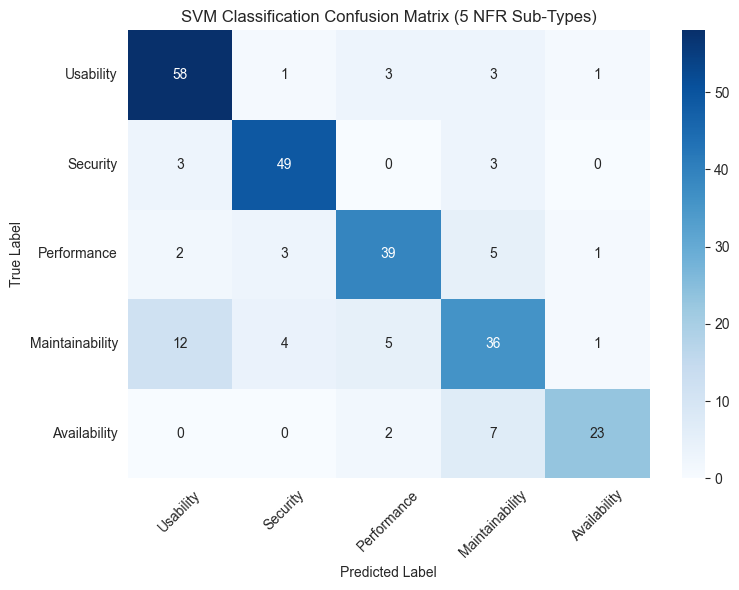

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. TF-IDF Vectorization
# Best-fix update: min_df=1 retains lower-frequency maintainability cues.
tf_vectorizer = TfidfVectorizer(ngram_range=(1, 3), max_df=0.85, min_df=1)
X_train_tfidf = tf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tf_vectorizer.transform(X_test_text)

# 2. Class-weighted SVM with GridSearchCV
# Best-fix update: use class_weight='balanced' instead of synthetic SMOTE vectors.
param_grid = {'C': [0.1, 0.5, 1.0, 5.0, 10.0]}
grid_svm = GridSearchCV(
    LinearSVC(random_state=42, dual=False, class_weight='balanced', max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
 )
grid_svm.fit(X_train_tfidf, y_train)

# Set the best model as our main classifier
clf_svm = grid_svm.best_estimator_
print(f"\nBest SVM C-parameter found: {grid_svm.best_params_['C']}")

# 3. Predict & Evaluate
y_pred_svm = clf_svm.predict(X_test_tfidf)

print(f"\nOptimized SVM (class-weighted, min_df=1) Accuracy: {accuracy_score(y_test, y_pred_svm) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=[inverse_label_mapping[i] for i in range(5)]))

# 4. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[inverse_label_mapping[i] for i in range(5)], 
            yticklabels=[inverse_label_mapping[i] for i in range(5)])
plt.title('SVM Classification Confusion Matrix (5 NFR Sub-Types)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_18018/1519567727.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
/tmp/ipykernel_18018/1519567727.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
/tmp/ipykernel_18018/1519567727.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
/tmp/ipykernel_18018/1519567727.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will 

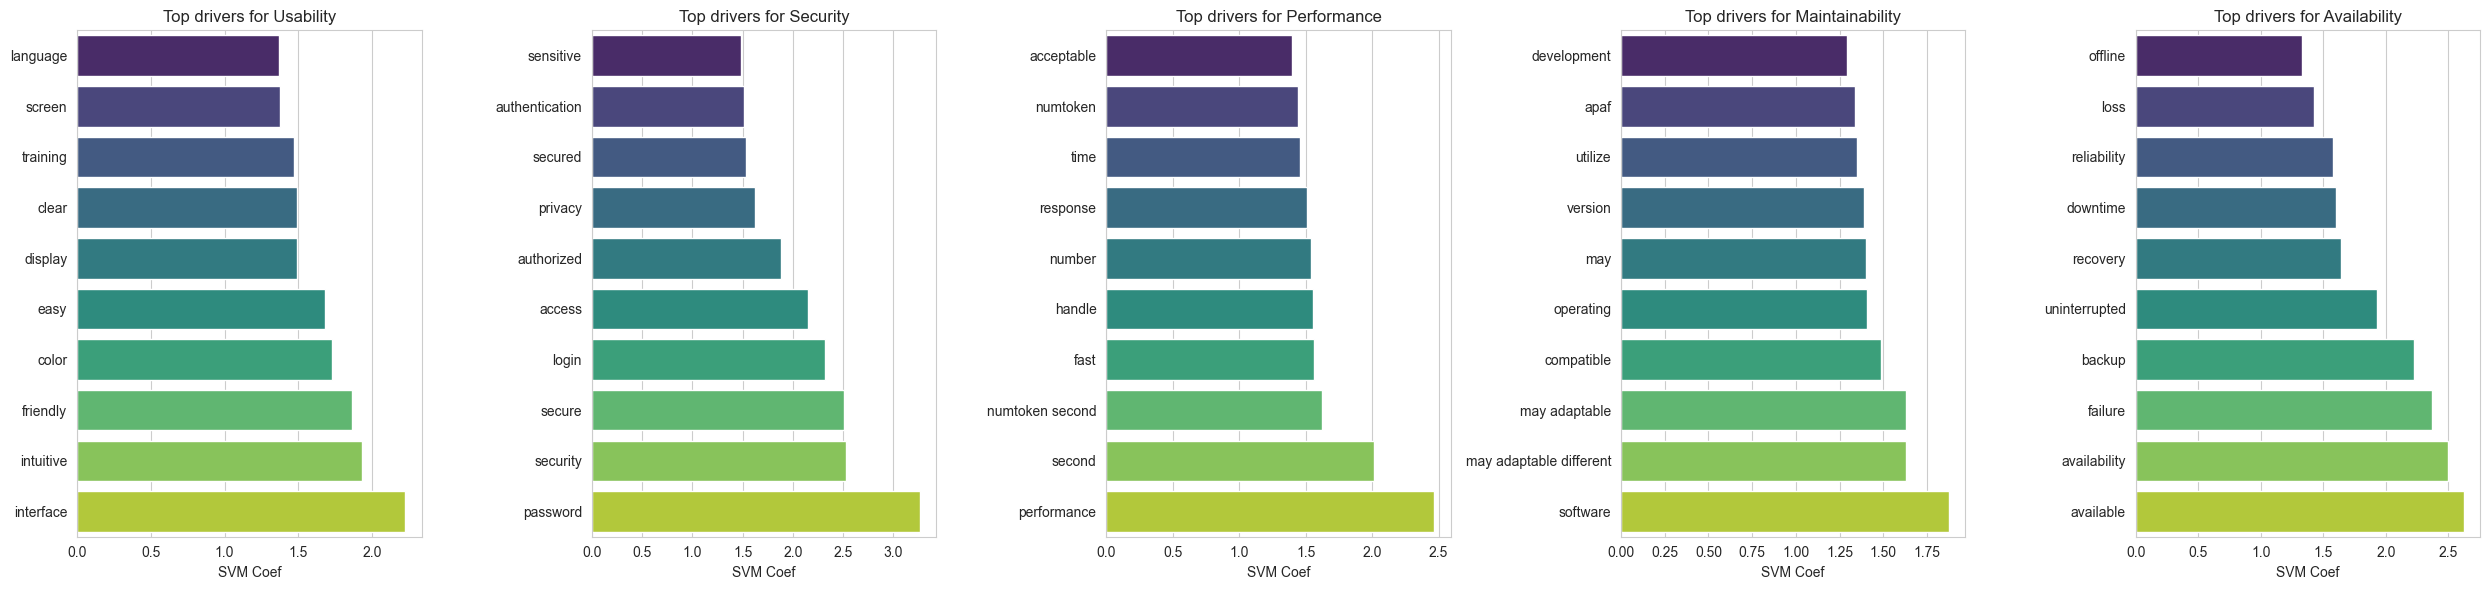

In [15]:
# --- Interpretability: Top SVM Features per Class ---
# Since LinearSVC uses a One-vs-Rest strategy for multi-class, it builds 5 separate models underneath.
# coef_ shape is (5, n_features)
feature_names = np.array(tf_vectorizer.get_feature_names_out())
svm_coefs = clf_svm.coef_

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

top_n = 10
for i, class_label in enumerate(target_classes):
    # Get standard sorted indices for this specific class's coefficients
    coef_i = svm_coefs[i]
    sorted_idx = coef_i.argsort()
    
    # Get the words with the highest positive coefficient for predicting THIS class vs the rest
    top_words_idx = sorted_idx[-top_n:]
    top_words = feature_names[top_words_idx]
    top_coefs = coef_i[top_words_idx]
    
    # Plot
    sns.barplot(x=top_coefs, y=top_words, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Top drivers for {class_label}")
    axes[i].set_xlabel("SVM Coef")
    if i > 0:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### 2. The Transformers Pipeline (DistilRoBERTa)
Because Hugging Face transformers need raw sequential text to understand context, we cannot use TF-IDF matrices or synthetic SMOTE vectors. Instead, we map labels, use `RandomOverSampler` to balance the text itself, tokenize it, and fine-tune a pre-trained `distilroberta-base` model.

In [16]:
import torch
import numpy as np
import inspect
from datasets import Dataset
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed,
 )

# Reproducibility
SEED = 42
set_seed(SEED)

# 1. Build Hugging Face datasets (no synthetic oversampling; use weighted loss instead)
train_hf = Dataset.from_dict({'text': X_train_text, 'label': y_train})
test_hf = Dataset.from_dict({'text': X_test_text, 'label': y_test})

# 2. Tokenizer + dynamic padding
model_name = 'distilroberta-base'
max_length = 192
tokenizer = AutoTokenizer.from_pretrained(model_name)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=max_length)

tokenized_train = train_hf.map(tokenize_function, batched=True)
tokenized_test = test_hf.map(tokenize_function, batched=True)

# 3. Compute class weights from original training distribution
class_ids = np.array(sorted(np.unique(y_train)))
class_weights_np = compute_class_weight(class_weight='balanced', classes=class_ids, y=y_train)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print('Class weights (balanced):')
for idx, w in zip(class_ids, class_weights_np):
    print(f"{inverse_label_mapping[int(idx)]}: {w:.4f}")

# 4. Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=5,
    id2label=inverse_label_mapping,
    label2id=label_mapping,
 )

# 5. Metrics: optimize for macro F1 (not only accuracy)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'macro_f1': f1_score(labels, predictions, average='macro'),
        'weighted_f1': f1_score(labels, predictions, average='weighted'),
    }

# 6. Weighted Trainer for class-imbalanced learning
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device, dtype=logits.dtype)
        )
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# 7. Training arguments (early stopping + warmup + best-model by macro F1)
training_args = TrainingArguments(
    output_dir='./results_roberta',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    lr_scheduler_type='linear',
    warmup_ratio=0.10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    num_train_epochs=6,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='eval_macro_f1',
    greater_is_better=True,
    save_total_limit=2,
    logging_steps=25,
    report_to='none',
    fp16=torch.cuda.is_available(),
 )

trainer_kwargs = dict(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_init_params = inspect.signature(Trainer.__init__).parameters
if 'tokenizer' in trainer_init_params:
    trainer_kwargs['tokenizer'] = tokenizer
elif 'processing_class' in trainer_init_params:
    trainer_kwargs['processing_class'] = tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

# 8. Train
print('\nStarting improved DistilRoBERTa training (weighted loss + macro F1 selection)...')
trainer.train()

/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Map: 100%|██████████| 261/261 [00:00<00:00, 39145.84 examples/s]


Class weights (balanced):
Usability: 0.7872
Security: 0.9439
Performance: 1.0430
Maintainability: 0.9109
Availability: 1.6297


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 1880.10it/s]
RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be re


Starting improved DistilRoBERTa training (weighted loss + macro F1 selection)...


/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,3.176410,1.032097,0.662835,0.622560,0.638593
2,1.355332,0.603391,0.785441,0.789211,0.790192
3,0.915101,0.544462,0.800766,0.797015,0.802742
4,0.579939,0.531174,0.816092,0.812910,0.816999
5,0.368857,0.569452,0.808429,0.804104,0.806843
6,0.384455,0.554254,0.819923,0.814649,0.818684


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.35it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.15it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Scien

TrainOutput(global_step=396, training_loss=1.1397938246678825, metrics={'train_runtime': 384.6531, 'train_samples_per_second': 16.269, 'train_steps_per_second': 1.029, 'total_flos': 27231010261350.0, 'train_loss': 1.1397938246678825, 'epoch': 6.0})

/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



DistilRoBERTa Accuracy: 81.99%

Classification Report:
                 precision    recall  f1-score   support

      Usability       0.89      0.89      0.89        66
       Security       0.88      0.91      0.89        55
    Performance       0.82      0.82      0.82        50
Maintainability       0.70      0.66      0.68        58
   Availability       0.76      0.81      0.79        32

       accuracy                           0.82       261
      macro avg       0.81      0.82      0.81       261
   weighted avg       0.82      0.82      0.82       261



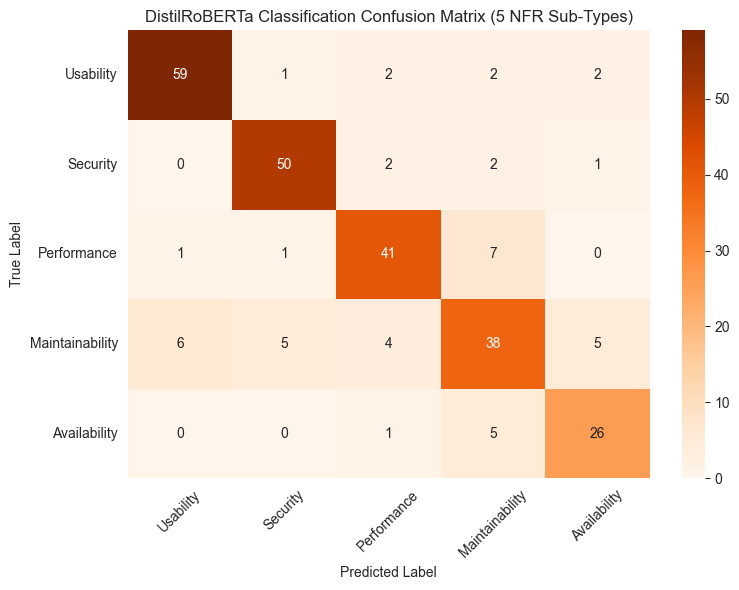

In [17]:
# --- 7. Evaluate DistilRoBERTa ---
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

predictions = trainer.predict(tokenized_test)
y_pred_roberta = np.argmax(predictions.predictions, axis=-1)

print(f"\nDistilRoBERTa Accuracy: {accuracy_score(y_test, y_pred_roberta) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_roberta, target_names=[inverse_label_mapping[i] for i in range(5)]))

# Confusion Matrix for RoBERTa
plt.figure(figsize=(8, 6))
cm_roberta = confusion_matrix(y_test, y_pred_roberta)
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=[inverse_label_mapping[i] for i in range(5)], 
            yticklabels=[inverse_label_mapping[i] for i in range(5)])
plt.title('DistilRoBERTa Classification Confusion Matrix (5 NFR Sub-Types)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

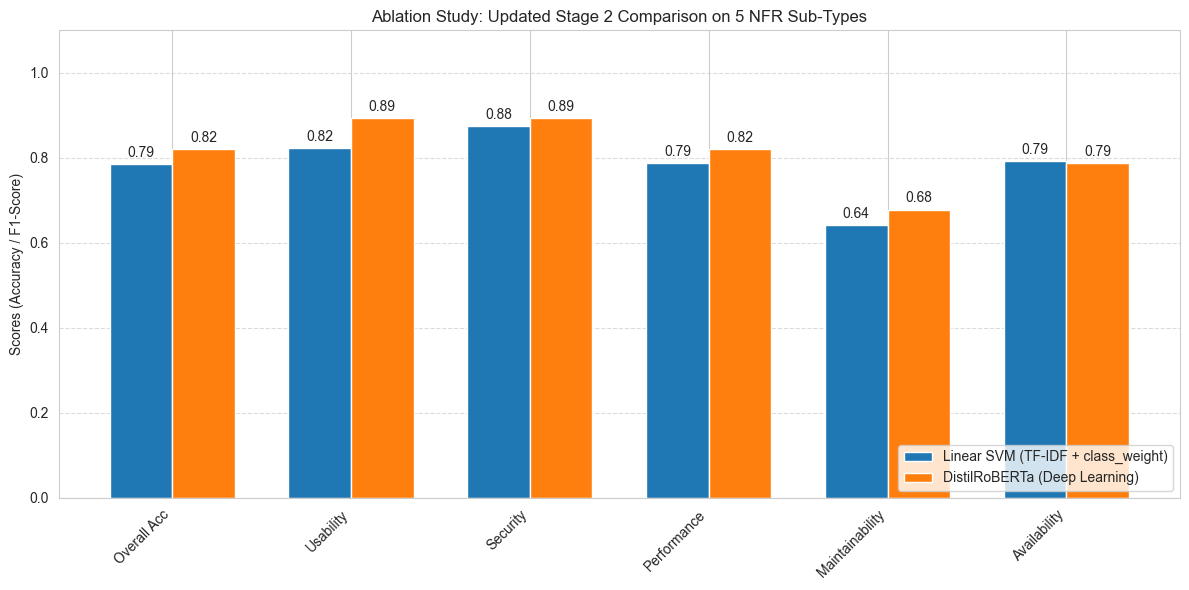

Updated Stage 2 Overall Accuracy -> SVM: 0.7854, DistilRoBERTa: 0.8199, Delta (RoBERTa - SVM): +0.0345


In [18]:
# --- 8. Ablation Study Comparison Chart (Class-Weighted SVM vs RoBERTa) ---
# Dynamically pull metrics from available predictions and recover missing ones when possible
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import json
from pathlib import Path

# Recover SVM predictions if missing
if 'y_pred_svm' not in globals():
    if 'clf_svm' in globals():
        if 'X_test_tfidf' in globals():
            y_pred_svm = clf_svm.predict(X_test_tfidf)
        elif 'tf_vectorizer' in globals() and 'X_test_text' in globals():
            X_test_tfidf = tf_vectorizer.transform(X_test_text)
            y_pred_svm = clf_svm.predict(X_test_tfidf)

# Recover RoBERTa predictions if missing
if 'y_pred_roberta' not in globals() and 'trainer' in globals() and 'tokenized_test' in globals():
    try:
        predictions = trainer.predict(tokenized_test)
        y_pred_roberta = np.argmax(predictions.predictions, axis=-1)
    except Exception as e:
        print(f"Could not recover y_pred_roberta from trainer: {e}")

if 'y_pred_svm' not in globals():
    print("SVM predictions are not available. Run Cell 12 (Stage 2 SVM) first, then re-run this cell.")
elif 'y_pred_roberta' in globals():
    report_svm = classification_report(
        y_test, y_pred_svm, target_names=[inverse_label_mapping[i] for i in range(5)], output_dict=True
    )
    report_roberta = classification_report(
        y_test, y_pred_roberta, target_names=[inverse_label_mapping[i] for i in range(5)], output_dict=True
    )

    metrics_labels = ['Overall Acc'] + [inverse_label_mapping[i] for i in range(5)]
    svm_scores = [report_svm['accuracy']] + [report_svm[inverse_label_mapping[i]]['f1-score'] for i in range(5)]
    roberta_scores = [report_roberta['accuracy']] + [report_roberta[inverse_label_mapping[i]]['f1-score'] for i in range(5)]

    x = np.arange(len(metrics_labels))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))
    rects1 = ax.bar(x - width/2, svm_scores, width, label='Linear SVM (TF-IDF + class_weight)', color='#1f77b4')
    rects2 = ax.bar(x + width/2, roberta_scores, width, label='DistilRoBERTa (Deep Learning)', color='#ff7f0e')

    ax.set_ylabel('Scores (Accuracy / F1-Score)')
    ax.set_title('Ablation Study: Updated Stage 2 Comparison on 5 NFR Sub-Types')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, rotation=45, ha='right')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.1)
    ax.bar_label(rects1, fmt='%.2f', padding=3)
    ax.bar_label(rects2, fmt='%.2f', padding=3)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    svm_acc = report_svm['accuracy']
    roberta_acc = report_roberta['accuracy']
    delta = roberta_acc - svm_acc
    print(
        f"Updated Stage 2 Overall Accuracy -> SVM: {svm_acc:.4f}, "
        f"DistilRoBERTa: {roberta_acc:.4f}, Delta (RoBERTa - SVM): {delta:+.4f}"
    )
else:
    # Fallback: if RoBERTa predictions are unavailable, try loading saved trainer_state accuracy
    report_svm = classification_report(
        y_test, y_pred_svm, target_names=[inverse_label_mapping[i] for i in range(5)], output_dict=True
    )

    checkpoints = sorted(Path('results_roberta').glob('checkpoint-*/trainer_state.json'))
    roberta_acc = None
    if checkpoints:
        latest = max(checkpoints, key=lambda p: p.stat().st_mtime)
        with open(latest, 'r') as f:
            trainer_state = json.load(f)
        eval_entries = [x for x in trainer_state.get('log_history', []) if 'eval_accuracy' in x]
        roberta_acc = eval_entries[-1]['eval_accuracy'] if eval_entries else None

    svm_acc = report_svm['accuracy']
    print('Note: y_pred_roberta is not defined in the current kernel.')

    if roberta_acc is not None:
        delta = roberta_acc - svm_acc
        print(
            f"Updated Stage 2 Overall Accuracy -> SVM: {svm_acc:.4f}, "
            f"DistilRoBERTa (from saved checkpoint log): {roberta_acc:.4f}, "
            f"Delta (RoBERTa - SVM): {delta:+.4f}"
        )

        plt.figure(figsize=(7, 4))
        labels = ['Class-weighted SVM', 'DistilRoBERTa']
        values = [svm_acc, roberta_acc]
        bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'])
        plt.title('Stage 2 Overall Accuracy Comparison (Fallback Mode)')
        plt.ylabel('Accuracy')
        plt.ylim(0, 1.0)
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.3f}', ha='center')
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print('RoBERTa saved accuracy not found. Run Cell 16 (RoBERTa evaluation) first for full comparison.')

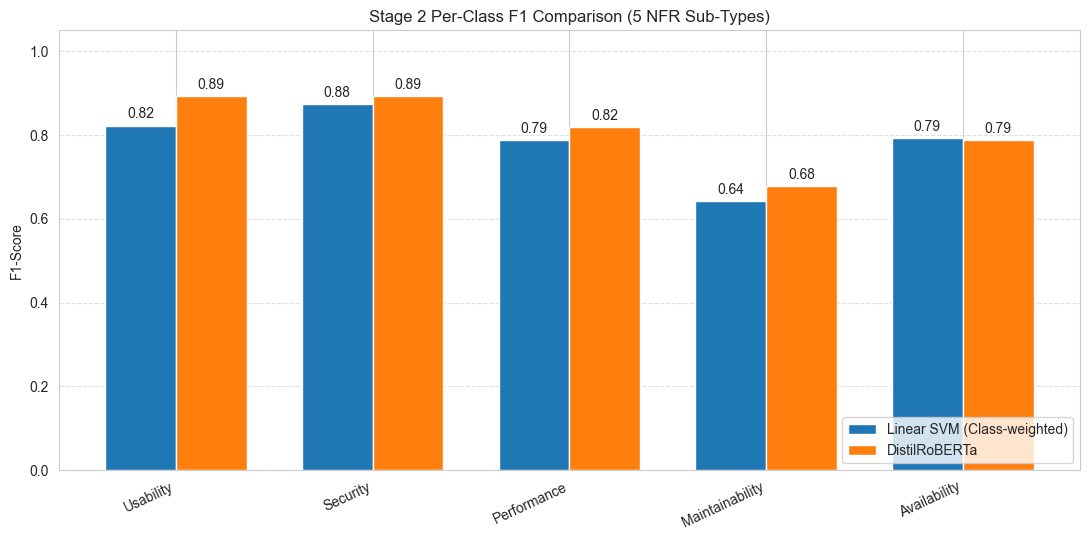

In [19]:
# --- 8.1 Per-Class Comparison Chart (5 NFR Types Only) ---
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# Try to recover RoBERTa predictions if they are not already present
if 'y_pred_roberta' not in globals() and 'trainer' in globals() and 'tokenized_test' in globals():
    try:
        predictions = trainer.predict(tokenized_test)
        y_pred_roberta = np.argmax(predictions.predictions, axis=-1)
    except Exception as e:
        print(f"Could not compute y_pred_roberta from trainer: {e}")

if 'y_pred_roberta' not in globals():
    print("Per-class chart requires y_pred_roberta. Run the DistilRoBERTa evaluation cell first.")
else:
    report_svm_types = classification_report(
        y_test,
        y_pred_svm,
        target_names=[inverse_label_mapping[i] for i in range(5)],
        output_dict=True,
    )
    report_roberta_types = classification_report(
        y_test,
        y_pred_roberta,
        target_names=[inverse_label_mapping[i] for i in range(5)],
        output_dict=True,
    )

    class_labels = [inverse_label_mapping[i] for i in range(5)]
    svm_f1_types = [report_svm_types[label]['f1-score'] for label in class_labels]
    roberta_f1_types = [report_roberta_types[label]['f1-score'] for label in class_labels]

    x_types = np.arange(len(class_labels))
    width = 0.36

    fig, ax = plt.subplots(figsize=(11, 5.5))
    bars_svm = ax.bar(x_types - width / 2, svm_f1_types, width, label='Linear SVM (Class-weighted)', color='#1f77b4')
    bars_roberta = ax.bar(x_types + width / 2, roberta_f1_types, width, label='DistilRoBERTa', color='#ff7f0e')

    ax.set_title('Stage 2 Per-Class F1 Comparison (5 NFR Sub-Types)')
    ax.set_ylabel('F1-Score')
    ax.set_xticks(x_types)
    ax.set_xticklabels(class_labels, rotation=25, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='lower right')
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)

    ax.bar_label(bars_svm, fmt='%.2f', padding=3)
    ax.bar_label(bars_roberta, fmt='%.2f', padding=3)

    plt.tight_layout()
    plt.show()

### 2.1 Stage 2 Quick Fixes: Maintainability-Focused SVM Variants

This section tests lightweight improvements to the Stage 2 TF-IDF + SVM pipeline:
- Lower `min_df` to retain rarer maintainability cues.
- Use `class_weight='balanced'` as an alternative to synthetic SMOTE vectors.
- Compare against the original baseline using the same train/test split.

The goal is to improve **Maintainability F1** without hurting overall accuracy.

In [20]:
# --- Stage 2 Quick Fix Evaluation (SVM variants) ---
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, accuracy_score


def evaluate_svm_variant(variant_name, min_df=3, balancing='smote'):
    vec = TfidfVectorizer(ngram_range=(1, 3), max_df=0.85, min_df=min_df)
    X_train_vec_var = vec.fit_transform(X_train_text)
    X_test_vec_var = vec.transform(X_test_text)

    if balancing == 'smote':
        sampler = SMOTE(random_state=42)
        X_fit, y_fit = sampler.fit_resample(X_train_vec_var, y_train)
        clf = LinearSVC(random_state=42, dual=False, max_iter=5000)
    elif balancing == 'random_over':
        sampler = RandomOverSampler(random_state=42)
        X_fit, y_fit = sampler.fit_resample(X_train_vec_var, y_train)
        clf = LinearSVC(random_state=42, dual=False, max_iter=5000)
    elif balancing == 'class_weight':
        X_fit, y_fit = X_train_vec_var, y_train
        clf = LinearSVC(random_state=42, dual=False, class_weight='balanced', max_iter=5000)
    else:
        X_fit, y_fit = X_train_vec_var, y_train
        clf = LinearSVC(random_state=42, dual=False, max_iter=5000)

    clf.fit(X_fit, y_fit)
    y_pred = clf.predict(X_test_vec_var)

    report = classification_report(
        y_test,
        y_pred,
        target_names=[inverse_label_mapping[i] for i in range(5)],
        output_dict=True,
    )

    return {
        'Variant': variant_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Maintainability_F1': report['Maintainability']['f1-score'],
        'Usability_F1': report['Usability']['f1-score'],
        'Security_F1': report['Security']['f1-score'],
        'Performance_F1': report['Performance']['f1-score'],
        'Availability_F1': report['Availability']['f1-score'],
    }


quick_fix_results = [
    evaluate_svm_variant('Baseline (min_df=3 + SMOTE)', min_df=3, balancing='smote'),
    evaluate_svm_variant('Fix A (min_df=1 + class_weight)', min_df=1, balancing='class_weight'),
    evaluate_svm_variant('Fix B (min_df=1 + RandomOverSampler)', min_df=1, balancing='random_over'),
    evaluate_svm_variant('Fix C (min_df=2 + class_weight)', min_df=2, balancing='class_weight'),
]

quick_fix_df = pd.DataFrame(quick_fix_results).sort_values('Maintainability_F1', ascending=False).reset_index(drop=True)

print('Stage 2 quick-fix ranking by Maintainability F1:')
display(quick_fix_df)

best_variant = quick_fix_df.iloc[0]
print(
    f"\nBest variant: {best_variant['Variant']} | "
    f"Maintainability F1={best_variant['Maintainability_F1']:.3f} | "
    f"Accuracy={best_variant['Accuracy']:.3f}"
)

# Optional visualization for dissertation-friendly comparison
plt.figure(figsize=(11, 4.5))
plot_cols = ['Accuracy', 'Maintainability_F1', 'Usability_F1', 'Security_F1', 'Performance_F1', 'Availability_F1']
plot_data = quick_fix_df.set_index('Variant')[plot_cols]
plot_data.plot(kind='bar', figsize=(12, 5), rot=20)
plt.title('Stage 2 Quick Fixes: Accuracy and Per-Class F1')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

NameError: name 'SMOTE' is not defined

# Stage 3: The Critic & ablation Study 

### Data Preparation: Ambiguity Classification (Downsampling)
Based on our discussion, we are making a few specific methodological changes for the final ambiguity classifier:
1. **Retaining Stopwords:** Words like "may", "might", "often", and "could" are crucial grammatical cues for ambiguity. We'll bypass the aggressive NLTK stopword filter used in the first two stages.
2. **Global Dataset Scope:** We are utilizing the entire dataset (FRs & NFRs) to maximise our training context.
3. **Downsampling:** To balance the ambiguous vs unambiguous labels, ensuring mathematical fairness.
4. **5 Epochs for Deep Learning:** We'll increase the training loops from 3 to 5 since downsampling results in slightly less data for RoBERTa to learn from.

In [21]:
import pandas as pd
import re
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# Reload the original uncut corpus
raw_corpus = pd.read_csv('final_corpus_verified - Sheet1.csv', nrows=4000)

# We define a softer cleaning function specifically for ambiguity that RETAINS stopwords
def clean_text_ambiguity(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    
    # Strip numerical bullet points at start
    text = re.sub(r'^\s*(?:\d+[\.\)]\s*)+', '', text)
    
    # Tokenize standard numbers to prevent overfitting on numeric specifics
    text = re.sub(r'\b\d+(?:\.\d+)?\b', 'numtoken', text)
    
    # Remove weird punctuation but explicitly KEEP stopwords and grammatical flow
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # Re-join to remove double spaces
    return " ".join(text.split())

df_amb = raw_corpus.copy()
# Ensure we drop any rows that inexplicably missed an Ambiguity label
df_amb = df_amb.dropna(subset=['Ambiguity'])

# Apply the new soft cleaning function
df_amb['cleaned_text'] = df_amb['Requirement Text'].apply(clean_text_ambiguity)

# Drop rows with < 3 words
df_amb = df_amb[df_amb['cleaned_text'].apply(lambda x: len(x.split()) >= 3)]

# Drop duplicates
df_amb = df_amb.drop_duplicates(subset=['cleaned_text'])

# Encode Ambiguity Labels dynamically 
# Typically: 'Ambiguous' and 'Non-Ambiguous' or similar binaries
df_amb['Ambiguity'] = df_amb['Ambiguity'].astype(str).str.strip()
ambiguity_classes = set(df_amb['Ambiguity'].unique().tolist()) - {'nan', 'None', ''}
ambiguity_classes = sorted(list(ambiguity_classes))

label_mapping_amb = {label: idx for idx, label in enumerate(ambiguity_classes)}
inverse_label_mapping_amb = {idx: label for label, idx in label_mapping_amb.items()}
df_amb['label'] = df_amb['Ambiguity'].map(label_mapping_amb)

print("Original Ambiguity Class Distribution:")
print(df_amb['Ambiguity'].value_counts())

# --- Downsampling to balance ---
class_counts = df_amb['label'].value_counts()
minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()
minority_count = class_counts.min()

df_majority = df_amb[df_amb['label'] == majority_class]
df_minority = df_amb[df_amb['label'] == minority_class]

df_majority_downsampled = resample(
    df_majority, 
    replace=False, 
    n_samples=minority_count, 
    random_state=42
)

# Combine and shuffle
df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced Ambiguity Class Distribution (After Downsampling):")
print(df_balanced['Ambiguity'].value_counts())

# Convert to plain NumPy object/int arrays to avoid pandas Arrow indexing issues in train_test_split
X_amb = df_balanced['cleaned_text'].astype(str).to_numpy(dtype=object)
y_amb = df_balanced['label'].astype(int).to_numpy()

# Split 80/20
X_train_amb, X_test_amb, y_train_amb, y_test_amb = train_test_split(
    X_amb, y_amb, test_size=0.2, stratify=y_amb, random_state=42
)

print(f"\nTraining set size: {len(X_train_amb)}")
print(f"Test set size: {len(X_test_amb)}")

Original Ambiguity Class Distribution:
Ambiguity
Non-Ambiguous    3370
Ambiguous         574
Name: count, dtype: int64

Balanced Ambiguity Class Distribution (After Downsampling):
Ambiguity
Non-Ambiguous    574
Ambiguous        574
Name: count, dtype: int64

Training set size: 918
Test set size: 230


### 1. Ambiguity: TF-IDF + SVM Pipeline

Optimised SVM C-parameter: 5.0
SVM Accuracy (Ambiguity): 73.48%

Classification Report:
               precision    recall  f1-score   support

    Ambiguous       0.76      0.68      0.72       115
Non-Ambiguous       0.71      0.79      0.75       115

     accuracy                           0.73       230
    macro avg       0.74      0.73      0.73       230
 weighted avg       0.74      0.73      0.73       230



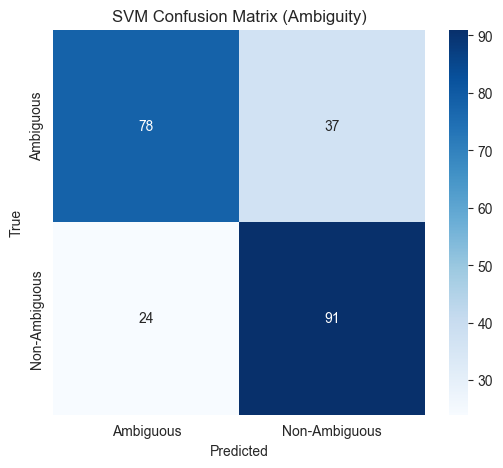

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# We still use N-Grams to catch phrases like "as soon as possible", "easy to use"
tf_vectorizer_amb = TfidfVectorizer(ngram_range=(1, 3), max_df=0.90, min_df=2)
X_train_tfidf_amb = tf_vectorizer_amb.fit_transform(X_train_amb)
X_test_tfidf_amb = tf_vectorizer_amb.transform(X_test_amb)

# Hyperparameter optimization array
param_grid_amb = {'C': [0.1, 0.5, 1.0, 5.0, 10.0]}
grid_svm_amb = GridSearchCV(LinearSVC(random_state=42, dual=False), param_grid_amb, cv=5, scoring='accuracy')
grid_svm_amb.fit(X_train_tfidf_amb, y_train_amb)

clf_svm_amb = grid_svm_amb.best_estimator_
y_pred_svm_amb = clf_svm_amb.predict(X_test_tfidf_amb)

print(f"Optimised SVM C-parameter: {grid_svm_amb.best_params_['C']}")
print(f"SVM Accuracy (Ambiguity): {accuracy_score(y_test_amb, y_pred_svm_amb) * 100:.2f}%\n")

target_names_amb = [inverse_label_mapping_amb[i] for i in range(len(ambiguity_classes))]
print("Classification Report:")
print(classification_report(y_test_amb, y_pred_svm_amb, target_names=target_names_amb))

plt.figure(figsize=(6, 5))
cm_amb = confusion_matrix(y_test_amb, y_pred_svm_amb)
sns.heatmap(cm_amb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names_amb, 
            yticklabels=target_names_amb)
plt.title('SVM Confusion Matrix (Ambiguity)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

### 2. Ambiguity: Deep Learning (DistilRoBERTa)
As discussed, adjusting from 3 to 5 epochs to compensate for the smaller total corpus size returned by downsampling.

In [23]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import numpy as np

# Convert clean text directly into HuggingFace dataset formats
train_hf_amb = Dataset.from_dict({'text': X_train_amb, 'label': y_train_amb})
test_hf_amb = Dataset.from_dict({'text': X_test_amb, 'label': y_test_amb})

model_name = "distilroberta-base"
tokenizer_amb = AutoTokenizer.from_pretrained(model_name)

def tokenize_function_amb(examples):
    return tokenizer_amb(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_train_amb = train_hf_amb.map(tokenize_function_amb, batched=True)
tokenized_test_amb = test_hf_amb.map(tokenize_function_amb, batched=True)

model_amb = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=len(ambiguity_classes), 
    id2label=inverse_label_mapping_amb, 
    label2id=label_mapping_amb
)

metric_amb = evaluate.load("accuracy")
def compute_metrics_amb(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric_amb.compute(predictions=predictions, references=labels)

training_args_amb = TrainingArguments(
    output_dir="./results_roberta_ambiguity",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,           
    weight_decay=0.01,
    load_best_model_at_end=True,
    logging_steps=50,
    report_to="none"
)

trainer_amb = Trainer(
    model=model_amb,
    args=training_args_amb,
    train_dataset=tokenized_train_amb,
    eval_dataset=tokenized_test_amb,
    compute_metrics=compute_metrics_amb,
)

print("\nStarting RoBERTa Training for Ambiguity...")
trainer_amb.train()

Loading weights: 100%|██████████| 101/101 [00:00<00:00, 1924.31it/s]
RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Starting RoBERTa Training for Ambiguity...


/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.648715,0.550165,0.739130
2,0.466220,0.505520,0.782609
3,0.386237,0.444058,0.821739
4,0.265448,0.490448,0.808696
5,0.248986,0.474854,0.826087


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]
/home/ajaz/Desktop/Heriot Watt Work/Computer Scien

TrainOutput(global_step=290, training_loss=0.37439767081162023, metrics={'train_runtime': 1185.6461, 'train_samples_per_second': 3.871, 'train_steps_per_second': 0.245, 'total_flos': 152006339957760.0, 'train_loss': 0.37439767081162023, 'epoch': 5.0})

/home/ajaz/Desktop/Heriot Watt Work/Computer Science (Year 4)/Semester 2/Design and Implementation _ Project Testing and Presentation (F20PB & F20PC)/PURR/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


DistilRoBERTa Accuracy (Ambiguity): 82.17%

Classification Report:
               precision    recall  f1-score   support

    Ambiguous       0.80      0.86      0.83       115
Non-Ambiguous       0.85      0.78      0.81       115

     accuracy                           0.82       230
    macro avg       0.82      0.82      0.82       230
 weighted avg       0.82      0.82      0.82       230



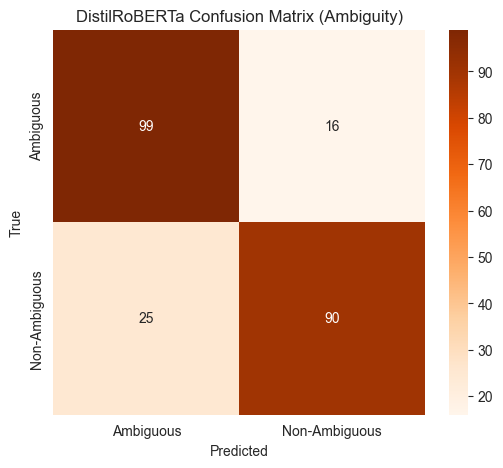

In [25]:
# --- Evaluate RoBERTa (Ambiguity) ---
predictions_amb = trainer_amb.predict(tokenized_test_amb)
y_pred_roberta_amb = np.argmax(predictions_amb.predictions, axis=-1)

print(f"DistilRoBERTa Accuracy (Ambiguity): {accuracy_score(y_test_amb, y_pred_roberta_amb) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test_amb, y_pred_roberta_amb, target_names=target_names_amb))

plt.figure(figsize=(6, 5))
cm_roberta_amb = confusion_matrix(y_test_amb, y_pred_roberta_amb)
sns.heatmap(cm_roberta_amb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=target_names_amb, 
            yticklabels=target_names_amb)
plt.title('DistilRoBERTa Confusion Matrix (Ambiguity)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

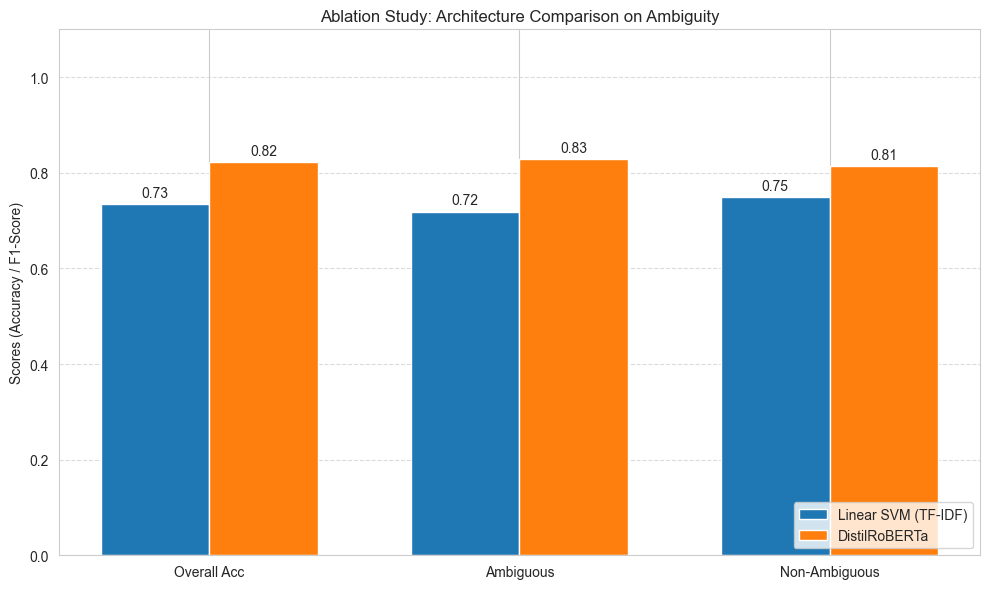

In [26]:
# --- Ambiguity Ablation Study Comparison Chart ---

report_svm_amb = classification_report(y_test_amb, y_pred_svm_amb, target_names=target_names_amb, output_dict=True)
report_roberta_amb = classification_report(y_test_amb, y_pred_roberta_amb, target_names=target_names_amb, output_dict=True)

metrics_labels_amb = ['Overall Acc'] + target_names_amb

svm_scores_amb = [report_svm_amb['accuracy']] + [report_svm_amb[name]['f1-score'] for name in target_names_amb]
roberta_scores_amb = [report_roberta_amb['accuracy']] + [report_roberta_amb[name]['f1-score'] for name in target_names_amb]

x_amb_plot = np.arange(len(metrics_labels_amb))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x_amb_plot - width/2, svm_scores_amb, width, label='Linear SVM (TF-IDF)', color='#1f77b4')
rects2 = ax.bar(x_amb_plot + width/2, roberta_scores_amb, width, label='DistilRoBERTa', color='#ff7f0e')

ax.set_ylabel('Scores (Accuracy / F1-Score)')
ax.set_title('Ablation Study: Architecture Comparison on Ambiguity')
ax.set_xticks(x_amb_plot)
ax.set_xticklabels(metrics_labels_amb)
ax.legend(loc='lower right')

ax.set_ylim(0, 1.1)

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Stage 4: Metadata-Aware LLM Rewrite (Local GGUF model)

This stage turns the pipeline into a true hybrid system by using the outputs of the previous stages as structured prompt context for the local LLM rewrite step.

### Metadata-aware prompting design

For each requirement, the rewrite prompt can use:
- predicted requirement class from Stage 1 (`FR` or `NFR`)
- predicted NFR subtype from Stage 2 (`Security`, `Performance`, `Availability`, `Usability`, `Maintainability`)
- predicted ambiguity label from Stage 3 (`Ambiguous` or `Non-Ambiguous`)

### Prompt variants for ablation

We compare four prompt strategies:
1. **plain**: rewrite with no metadata
2. **ambiguity_only**: rewrite with only ambiguity context
3. **metadata**: rewrite with class, subtype, and ambiguity context
4. **metadata_rules**: rewrite with metadata plus subtype-specific rewriting guidance

### Evaluation idea

Since a gold rewrite set may not yet exist, the first automatic evaluation checks whether the rewritten outputs are less likely to be predicted as ambiguous by the Stage 3 ambiguity classifier. This gives us an initial ablation study for the dissertation.

In [ ]:
%pip install -q llama-cpp-python


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
from pathlib import Path
import re
from llama_cpp import Llama
import pandas as pd

# Defensive setup: load corpus if this kernel session has not run earlier prep cells yet.
if 'raw_corpus' not in globals():
    print("`raw_corpus` not found in memory. Loading from CSV now...")
    raw_corpus = pd.read_csv('final_corpus_verified - Sheet1.csv', nrows=4000)

# Validate required upstream objects from Stages 1-3.
required_symbols = [
    'clean_text',
    'clean_text_ambiguity',
    'svm_model',
    'vectorizer',
    'clf_svm_amb',
    'tf_vectorizer_amb',
    'inverse_label_mapping_amb',
    'clf_svm',
    'inverse_label_mapping'
 ]
missing_symbols = [name for name in required_symbols if name not in globals()]
if missing_symbols:
    raise RuntimeError(
        "Stage 4 requires Stage 1-3 artifacts not found in memory: "
        + ", ".join(missing_symbols)
        + ". Run notebook cells for Stage 1, Stage 2 (SVM), and Stage 3 before Stage 4."
    )

# Path to local gguf model (ensure file exists)
model_path = Path('models/Meta-Llama-3-8B-Instruct.Q8_0.gguf')
if not model_path.exists():
    raise FileNotFoundError(f"Model not found: {model_path}")

print('Loading local GGUF model (this may take a moment)...')
llm = Llama(
    model_path=str(model_path),
    n_ctx=2048,
    verbose=False
)
print('Model loaded.')

# Rebuild a single input table and attach predicted metadata from earlier stages
rewrite_source = raw_corpus.copy()
rewrite_source = rewrite_source.dropna(subset=['Requirement Text']).copy()
rewrite_source['cleaned_text_stage1'] = rewrite_source['Requirement Text'].apply(clean_text)
rewrite_source['cleaned_text_stage3'] = rewrite_source['Requirement Text'].apply(clean_text_ambiguity)

rewrite_source = rewrite_source[rewrite_source['cleaned_text_stage3'].apply(lambda x: len(str(x).split()) >= 3)].copy()
rewrite_source = rewrite_source.drop_duplicates(subset=['cleaned_text_stage3']).reset_index(drop=True)

rewrite_source['predicted_class_id'] = svm_model.predict(vectorizer.transform(rewrite_source['cleaned_text_stage1']))
rewrite_source['predicted_class'] = rewrite_source['predicted_class_id'].map({0: 'FR', 1: 'NFR'})

rewrite_source['predicted_ambiguity_id'] = clf_svm_amb.predict(
    tf_vectorizer_amb.transform(rewrite_source['cleaned_text_stage3'])
)
rewrite_source['predicted_ambiguity'] = rewrite_source['predicted_ambiguity_id'].map(inverse_label_mapping_amb)

rewrite_source['predicted_subtype'] = 'N/A'
nfr_mask = rewrite_source['predicted_class'] == 'NFR'
if nfr_mask.any():
    rewrite_source.loc[nfr_mask, 'predicted_subtype_id'] = clf_svm.predict(
        tf_vectorizer.transform(rewrite_source.loc[nfr_mask, 'cleaned_text_stage1'])
    )
    rewrite_source.loc[nfr_mask, 'predicted_subtype'] = rewrite_source.loc[nfr_mask, 'predicted_subtype_id'].astype(int).map(inverse_label_mapping)

display_columns = [
    'Requirement Text',
    'predicted_class',
    'predicted_subtype',
    'predicted_ambiguity'
]
print('Metadata-aware rewrite pool prepared.')
display(rewrite_source[display_columns].head())

SUBTYPE_GUIDANCE = {
    'Security': 'Remove vague words like secure or protected unless a concrete security mechanism, access-control rule, audit rule, or encryption requirement is stated explicitly.',
    'Performance': 'Replace vague speed wording with measurable latency, throughput, response-time, or capacity targets whenever they are implied by the original requirement.',
    'Availability': 'Clarify uptime, recovery, failover, resilience, or service continuity expectations in measurable operational terms.',
    'Usability': 'Make user interaction expectations observable and testable, such as task completion, accessibility, feedback, learnability, or error-prevention behaviour.',
    'Maintainability': 'Clarify constraints around modularity, testability, diagnosability, configurability, or ease of change without adding unrelated detail.'
}

def normalize_rewrite_output(text):
    if not isinstance(text, str):
        return ''
    t = text.strip()

    # Remove markdown/code-fence blocks and common boilerplate prefixes.
    t = re.sub(r'```.*?```', ' ', t, flags=re.DOTALL)
    t = re.sub(r'(?i)^\s*(solution|rewritten requirement|note|explanation)\s*:\s*', '', t)
    t = re.sub(r'\s+', ' ', t).strip()

    # Keep the first requirement-like sentence.
    parts = re.split(r'(?<=[.!?])\s+', t)
    for p in parts:
        if re.search(r'\b(shall|must|should)\b', p.lower()):
            return p.strip().strip('"')

    return parts[0].strip().strip('"') if parts else t

def build_prompt(requirement_text, predicted_class, predicted_subtype, predicted_ambiguity, variant='metadata_rules'):
    base_instruction = (
        'You are an expert software requirements engineer. Rewrite the requirement to be clear, unambiguous, concise, testable, and implementation-ready. Preserve the original meaning and do not invent new product features.'
    )

    if variant == 'plain':
        context = 'No structured metadata is provided.'
    elif variant == 'ambiguity_only':
        context = f'Ambiguity prediction: {predicted_ambiguity}.'
    elif variant == 'metadata':
        context = f'Metadata: class={predicted_class}, subtype={predicted_subtype}, ambiguity={predicted_ambiguity}.'
    else:
        subtype_rule = SUBTYPE_GUIDANCE.get(predicted_subtype, 'Make the requirement specific, testable, and implementation-ready without changing its meaning.')
        context = f'Metadata: class={predicted_class}, subtype={predicted_subtype}, ambiguity={predicted_ambiguity}. {subtype_rule}'

    output_rules = (
        'Output rules: Return exactly one rewritten requirement sentence. No explanation, no bullets, no markdown, no quotes.'
    )

    prompt = (
        f'{base_instruction}\n\n'
        f'{context}\n'
        f'{output_rules}\n\n'
        f'Original requirement:\n{requirement_text}\n\n'
        f'Rewritten requirement:'
    )
    return prompt

def rewrite_requirement(requirement_text, predicted_class, predicted_subtype, predicted_ambiguity, variant='metadata_rules', max_tokens=96, temperature=0.0):
    prompt = build_prompt(
        requirement_text=requirement_text,
        predicted_class=predicted_class,
        predicted_subtype=predicted_subtype,
        predicted_ambiguity=predicted_ambiguity,
        variant=variant
    )
    resp = llm(
        prompt,
        max_tokens=max_tokens,
        temperature=temperature,
        repeat_penalty=1.15,
        stop=['\n\n', 'Explanation:', 'Note:', '```']
    )
    raw = resp['choices'][0]['text'] if 'choices' in resp and len(resp['choices']) > 0 else resp.get('text', '')
    return normalize_rewrite_output(raw)

Loading local GGUF model (this may take a moment)...


llama_context: n_ctx_per_seq (2048) < n_ctx_train (8192) -- the full capacity of the model will not be utilized


Model loaded.
Metadata-aware rewrite pool prepared.


,Requirement Text,predicted_class,predicted_subtype,predicted_ambiguity
0,The app shall run on a smart phone with Androi...,NFR,Maintainability,Non-Ambiguous
1,All layout shall be according to the TU/e corp...,NFR,Usability,Non-Ambiguous
2,The icons shall be according to the Android Ic...,NFR,Usability,Non-Ambiguous
3,The user interfaces shall be according to the ...,NFR,Usability,Non-Ambiguous
4,"The Twitter ""tweet"" interface shall be accordi...",NFR,Usability,Non-Ambiguous


### Stage 4.1 Rewrite generation and ablation setup

The next cell runs the local LLM over the same requirements using all prompt variants, then stores the outputs for side-by-side comparison and later evaluation. By default, rewriting is limited to requirements predicted as ambiguous, which is the main experimental condition for the dissertation.

In [28]:
from IPython.display import display

rewrite_only_ambiguous = True
prompt_variants = ['plain', 'ambiguity_only', 'metadata', 'metadata_rules']
batch_size = 100  # larger sample for more stable ablation estimates

rewrite_candidates = rewrite_source.copy()
if rewrite_only_ambiguous:
    rewrite_candidates = rewrite_candidates[rewrite_candidates['predicted_ambiguity'] == 'Ambiguous'].copy()

n = min(batch_size, len(rewrite_candidates)) if batch_size is not None else len(rewrite_candidates)
rewrite_candidates = rewrite_candidates.iloc[:n].copy().reset_index(drop=True)

print(f'Generating rewrites for {len(rewrite_candidates)} requirements across {len(prompt_variants)} prompt variants...')

for variant in prompt_variants:
    variant_outputs = []
    for i, row in rewrite_candidates.iterrows():
        print(f'[{variant}] {i + 1}/{len(rewrite_candidates)}', end='\r')
        try:
            rewritten = rewrite_requirement(
                requirement_text=row['Requirement Text'],
                predicted_class=row['predicted_class'],
                predicted_subtype=row['predicted_subtype'],
                predicted_ambiguity=row['predicted_ambiguity'],
                variant=variant
)
        except Exception as e:
            rewritten = f'<ERROR: {e}>'
        variant_outputs.append(rewritten)
    rewrite_candidates[f'llm_rewrite_{variant}'] = variant_outputs
    print(f'Completed variant: {variant}'.ljust(80))

out_csv = 'llm_rewrites_ablation.csv'
rewrite_candidates.to_csv(out_csv, index=False)
print(f'Saved ablation rewrite outputs to {out_csv}')

comparison_columns = [
    'Requirement Text',
    'predicted_class',
    'predicted_subtype',
    'predicted_ambiguity',
] + [f'llm_rewrite_{variant}' for variant in prompt_variants]

display(rewrite_candidates[comparison_columns].head(5))

Generating rewrites for 100 requirements across 4 prompt variants...
Completed variant: plain                                                        
Completed variant: ambiguity_only                                               
Completed variant: metadata                                                     
Completed variant: metadata_rules                                               
Saved ablation rewrite outputs to llm_rewrites_ablation.csv


,Requirement Text,predicted_class,predicted_subtype,predicted_ambiguity,llm_rewrite_plain,llm_rewrite_ambiguity_only,llm_rewrite_metadata,llm_rewrite_metadata_rules
0,The campus map shall cover the campus of the T...,FR,N/A,Ambiguous,The campus map shall provide a visual represen...,The campus map shall provide a comprehensive v...,The campus map shall provide a visual represen...,The campus map shall provide a visual represen...
1,The campus map shall cover the central train s...,FR,N/A,Ambiguous,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...
2,A new stylistic map must have the right dimens...,NFR,Usability,Ambiguous,The new stylistic map must have a predefined s...,The new stylistic map must have a predefined s...,The new stylistic map must have a fixed aspect...,The new stylistic map must have a fixed aspect...
3,Information about a certain person will be res...,FR,N/A,Ambiguous,The system shall restrict access to informatio...,The system shall restrict access to informatio...,The system shall restrict access to informatio...,The system shall restrict access to informatio...
4,The information and the search methods of the ...,FR,N/A,Ambiguous,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...


In [29]:
# Quick preview of original requirement, predicted metadata, and rewrite variants
preview_columns = [
    'Requirement Text',
    'predicted_class',
    'predicted_subtype',
    'predicted_ambiguity',
    'llm_rewrite_plain',
    'llm_rewrite_ambiguity_only',
    'llm_rewrite_metadata',
    'llm_rewrite_metadata_rules'
    ]
display(rewrite_candidates[preview_columns].head(10))

,Requirement Text,predicted_class,predicted_subtype,predicted_ambiguity,llm_rewrite_plain,llm_rewrite_ambiguity_only,llm_rewrite_metadata,llm_rewrite_metadata_rules
0,The campus map shall cover the campus of the T...,FR,N/A,Ambiguous,The campus map shall provide a visual represen...,The campus map shall provide a comprehensive v...,The campus map shall provide a visual represen...,The campus map shall provide a visual represen...
1,The campus map shall cover the central train s...,FR,N/A,Ambiguous,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...,The campus map shall include a detailed repres...
2,A new stylistic map must have the right dimens...,NFR,Usability,Ambiguous,The new stylistic map must have a predefined s...,The new stylistic map must have a predefined s...,The new stylistic map must have a fixed aspect...,The new stylistic map must have a fixed aspect...
3,Information about a certain person will be res...,FR,N/A,Ambiguous,The system shall restrict access to informatio...,The system shall restrict access to informatio...,The system shall restrict access to informatio...,The system shall restrict access to informatio...
4,The information and the search methods of the ...,FR,N/A,Ambiguous,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...,The Encyclopedia-app shall only provide access...
5,The information and the search methods of the ...,FR,N/A,Ambiguous,The Student Handbook-app will restrict access ...,The Student Handbook-app will restrict access ...,The Student Handbook-app shall restrict access...,The Student Handbook-app will restrict access ...
6,System dependability ensures users are informe...,NFR,Performance,Ambiguous,The system shall provide users with timely not...,The system shall provide users with timely and...,The system shall provide real-time notificatio...,The system shall provide real-time notificatio...
7,The application should ideally use less than 1...,NFR,Performance,Ambiguous,The application must use less than 10 MB of st...,The application must use less than 10 MB of st...,The application must use less than 10 MB of st...,The application must use no more than 10 MB of...
8,The applications memory usage on the mobile op...,NFR,Performance,Ambiguous,The mobile application's memory usage on the o...,The mobile application's memory usage on the o...,The mobile application's memory usage on the o...,The mobile operating system must ensure that t...
9,The system should reliably deliver accurate se...,NFR,Performance,Ambiguous,The system shall deliver accurate search resul...,The system shall return accurate search result...,The system shall deliver accurate search resul...,The system shall achieve a search result accur...


### Stage 4.2 Automatic evaluation of rewrite variants

This first evaluation pass uses the Stage 3 ambiguity classifier as an automatic proxy. A lower post-rewrite ambiguity rate indicates clearer rewrites under the same classifier.

To make this more reliable, the evaluation now includes:
- output normalization (remove explanations/markdown artifacts from model responses),
- direct comparison to a baseline ambiguity rate computed on the original requirements,
- ambiguity reduction score (`baseline - post_rewrite`) per prompt variant,
- average rewrite length as a guardrail against over-expansion.

Baseline ambiguous rate (before rewrite): 1.000


,variant,baseline_ambiguous_rate,ambiguous_rate_after,ambiguity_reduction,avg_rewrite_length_words
3,metadata_rules,1.0,0.63,0.37,25.38
2,metadata,1.0,0.75,0.25,23.06
1,ambiguity_only,1.0,0.77,0.23,21.47
0,plain,1.0,0.81,0.19,21.53


/tmp/ipykernel_18018/571840620.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation_eval_df, x='variant', y='ambiguous_rate_after', palette='viridis')


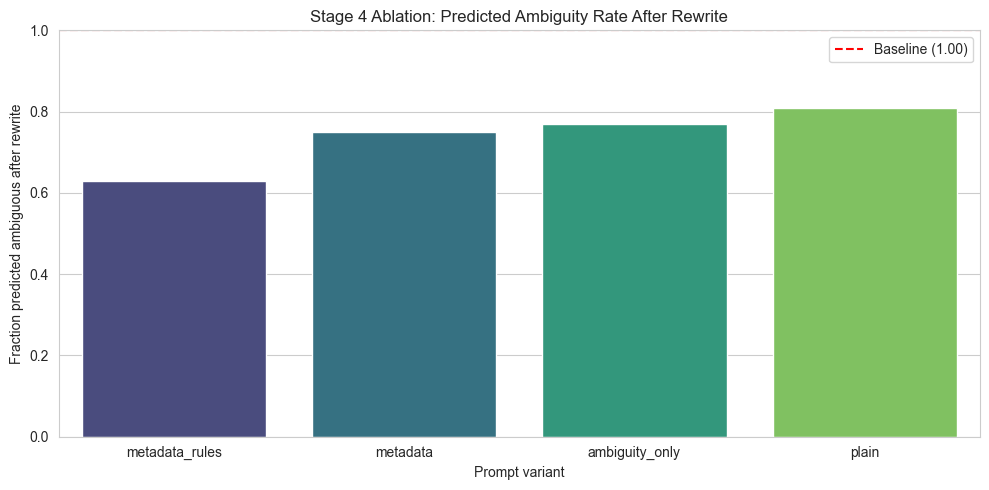

/tmp/ipykernel_18018/571840620.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation_eval_df, x='variant', y='avg_rewrite_length_words', palette='magma')


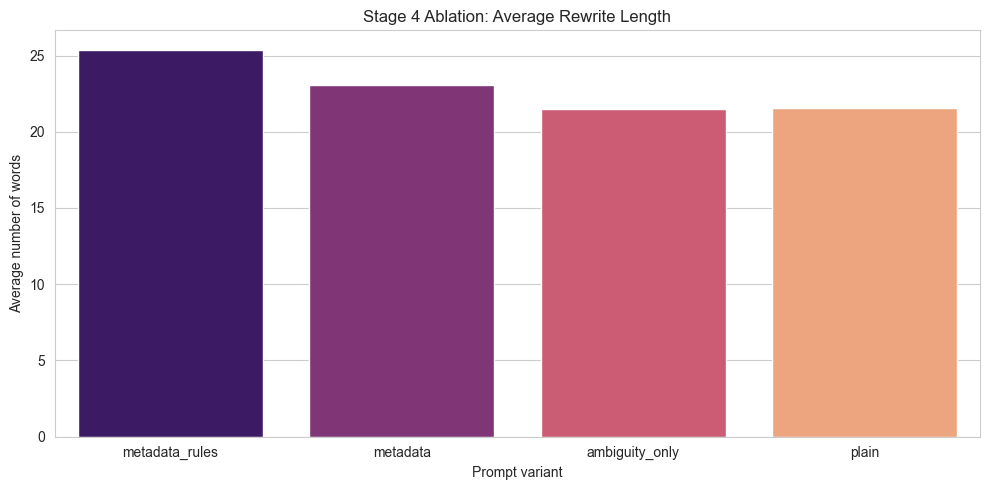

/tmp/ipykernel_18018/571840620.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ablation_eval_df, x='variant', y='ambiguity_reduction', palette='crest')


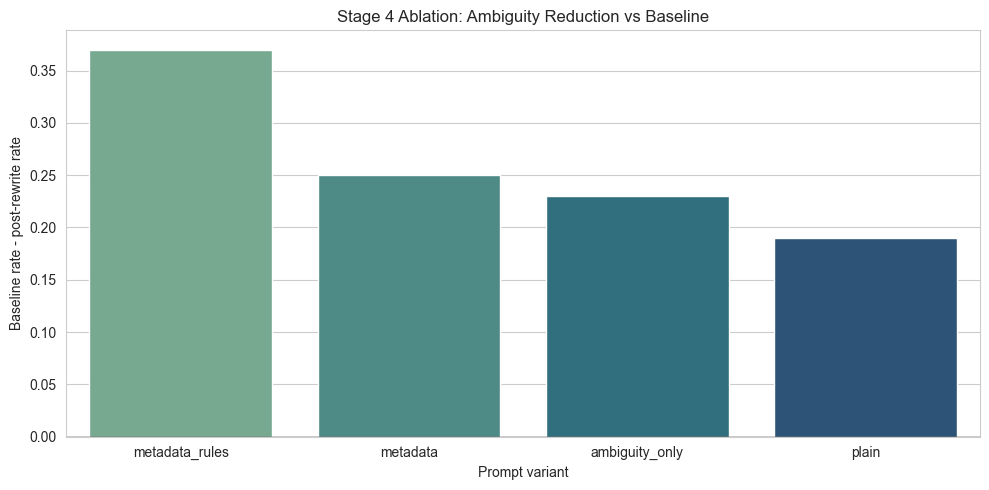

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

evaluation_rows = []
ambiguous_label_name = None
for label_name in target_names_amb:
    if 'ambig' in label_name.lower() and 'non' not in label_name.lower():
        ambiguous_label_name = label_name
        break

if ambiguous_label_name is None:
    ambiguous_label_name = target_names_amb[0]

ambiguous_label_id = label_mapping_amb[ambiguous_label_name]

# Baseline (before rewrite) on the same candidate subset
baseline_clean = rewrite_candidates['Requirement Text'].fillna('').apply(clean_text_ambiguity)
baseline_pred = clf_svm_amb.predict(tf_vectorizer_amb.transform(baseline_clean))
baseline_ambiguous_rate = float((baseline_pred == ambiguous_label_id).mean())
print(f'Baseline ambiguous rate (before rewrite): {baseline_ambiguous_rate:.3f}')

for variant in prompt_variants:
    rewritten_col = f'llm_rewrite_{variant}'
    normalized_variant = rewrite_candidates[rewritten_col].fillna('').apply(normalize_rewrite_output)
    cleaned_variant = normalized_variant.apply(clean_text_ambiguity)
    X_variant = tf_vectorizer_amb.transform(cleaned_variant)
    y_variant_pred = clf_svm_amb.predict(X_variant)

    rewrite_candidates[f'predicted_ambiguity_after_{variant}'] = y_variant_pred
    rewrite_candidates[f'llm_rewrite_{variant}_clean'] = normalized_variant

    ambiguous_rate_after = float((y_variant_pred == ambiguous_label_id).mean())
    avg_length = float(cleaned_variant.apply(lambda x: len(str(x).split())).mean())

    evaluation_rows.append({
        'variant': variant,
        'baseline_ambiguous_rate': baseline_ambiguous_rate,
        'ambiguous_rate_after': ambiguous_rate_after,
        'ambiguity_reduction': baseline_ambiguous_rate - ambiguous_rate_after,
        'avg_rewrite_length_words': avg_length
    })

ablation_eval_df = pd.DataFrame(evaluation_rows).sort_values('ambiguous_rate_after')
display(ablation_eval_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=ablation_eval_df, x='variant', y='ambiguous_rate_after', palette='viridis')
plt.axhline(baseline_ambiguous_rate, color='red', linestyle='--', label=f'Baseline ({baseline_ambiguous_rate:.2f})')
plt.title('Stage 4 Ablation: Predicted Ambiguity Rate After Rewrite')
plt.ylabel('Fraction predicted ambiguous after rewrite')
plt.xlabel('Prompt variant')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=ablation_eval_df, x='variant', y='avg_rewrite_length_words', palette='magma')
plt.title('Stage 4 Ablation: Average Rewrite Length')
plt.ylabel('Average number of words')
plt.xlabel('Prompt variant')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=ablation_eval_df, x='variant', y='ambiguity_reduction', palette='crest')
plt.axhline(0, color='black', linewidth=1)
plt.title('Stage 4 Ablation: Ambiguity Reduction vs Baseline')
plt.ylabel('Baseline rate - post-rewrite rate')
plt.xlabel('Prompt variant')
plt.tight_layout()
plt.show()